In [1]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Concatenate
from tcn import TCN
rng = np.random.default_rng(72)
tf.keras.utils.set_random_seed(72)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [2]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [3]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 64 … 77


In [4]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (99996, 82)
Global Participant_ID range: 6 … 77


In [5]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,20621,1750719007400,1647,1625,1610,1610,1592,1569,1580,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99992,20622,1750719007600,1637,1611,1592,1596,1570,1569,1575,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99993,20623,1750719007800,1607,1607,1592,1595,1568,1567,1560,1566,...,7.7,water,n,0,0,False,False,5,0.0,0
99994,20624,1750719008000,1602,1593,1586,1585,1568,1562,1560,1560,...,7.7,water,n,0,0,False,False,5,0.0,0


In [6]:
df = df_all

In [7]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [8]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 8                                   # 1 = ragged, >1 = padded


In [9]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# # ====================================================================
# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:                                # ← drop empty sip
#         skip_count += 1
#         continue
#     X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
#     y.append(dV)

# y = np.asarray(y, np.float32)
# X = np.array(X, dtype=object)   # each element is still a (T,64) array
# print(f"Total sips kept : {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", y.min(), "max:", y.max())

In [10]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================

# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=0.01):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- You control this threshold: sips longer than this will be augmented
# AUGMENT_IF_LONGER_THAN = 15  # You can change this

# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     X.append(sip_frames)
#     y.append(dV)

#     # Augment only if sip is long
#     if T > AUGMENT_IF_LONGER_THAN:
#         # 1. Add Gaussian noise
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         # 2. Flip horizontally
#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))


In [11]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================


# df = df[df["Label"] == 1]  # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=40):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- Thresholds you control
# AUGMENT_IF_LONGER_THAN = 15           # Regular augmentation if T > this
# MORE_AUGMENT_IF_LONGER_THAN = 20      # Extra augmentation if T > this
# NUM_EXTRA_NOISY_COPIES = 5            # Number of additional noise versions for long sips
# NUM_EXTRA_NOISY_COPIES_2 =7
# MORE_AUGMENT_IF_LONGER_THAN_2= 34
# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     # Original sip
#     X.append(sip_frames)
#     y.append(dV)

#     # Moderate-length sip → 1 noise + 1 flip
#     if T > AUGMENT_IF_LONGER_THAN:
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)

#     # Extra-long sip → multiple noise augmentations
#     if T > MORE_AUGMENT_IF_LONGER_THAN:
#         for _ in range(NUM_EXTRA_NOISY_COPIES):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)
#     if T > MORE_AUGMENT_IF_LONGER_THAN_2:
#         for _ in range(NUM_EXTRA_NOISY_COPIES_2):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)        

# # Final conversion to array
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))



In [12]:
# ====================================================================
# 1. load data ➜ X (list of (T,64)), y (array), X_aux (structured) – SKIP zero-volume sips – APPLY AUGMENTATION
# ====================================================================

df = df[df["Label"] == 1].copy()  
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# --- Augmentation Functions ---
def add_gaussian_noise(sip, std_dev=40):
    noise = np.random.normal(0, std_dev, sip.shape)
    return sip + noise

def flip_horizontal(sip):
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

# --- Thresholds
AUGMENT_IF_LONGER_THAN = 15
MORE_AUGMENT_IF_LONGER_THAN = 20
NUM_EXTRA_NOISY_COPIES = 5
MORE_AUGMENT_IF_LONGER_THAN_2 = 34
NUM_EXTRA_NOISY_COPIES_2 = 12

# --- Main data lists
X, y, X_aux = [], [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:
        skip_count += 1
        continue

    sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
    T = len(sip_frames)

    # Structured features (same for all versions of this sip)
    gender = g["Gender"].iloc[0]
    weight = g["Container_Weight"].iloc[0]
    temp = g["temp"].iloc[0]
    time_steps = T

    aux_features = np.array([gender, weight, temp, time_steps], dtype=np.float32)

    # Original sip
    X.append(sip_frames)
    y.append(dV)
    X_aux.append(aux_features)

    # Augment: Moderate-length → 1 noise + 1 flip
    if T > AUGMENT_IF_LONGER_THAN:
        noisy_sip = add_gaussian_noise(sip_frames)
        X.append(noisy_sip)
        y.append(dV)
        X_aux.append(aux_features)

        flipped_sip = flip_horizontal(sip_frames)
        X.append(flipped_sip)
        y.append(dV)
        X_aux.append(aux_features)

    # Augment: Extra-long sips → multiple noises
    if T > MORE_AUGMENT_IF_LONGER_THAN:
        for _ in range(NUM_EXTRA_NOISY_COPIES):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV)
            X_aux.append(aux_features)

    if T > MORE_AUGMENT_IF_LONGER_THAN_2:
        for _ in range(NUM_EXTRA_NOISY_COPIES_2):
            noisy_version = add_gaussian_noise(sip_frames)
            X.append(noisy_version)
            y.append(dV)
            X_aux.append(aux_features)

# Convert to arrays
X = np.array(X, dtype=object)                # List of (T, 64)
y = np.array(y, dtype=np.float32)            # Labels
X_aux = np.array(X_aux, dtype=np.float32)    # (N, 4)

print(f"Total sips kept (including augmented): {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", min(y), "max:", max(y))
print("Auxiliary feature shape →", X_aux.shape)


Total sips kept (including augmented): 1390
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2
Auxiliary feature shape → (1390, 4)


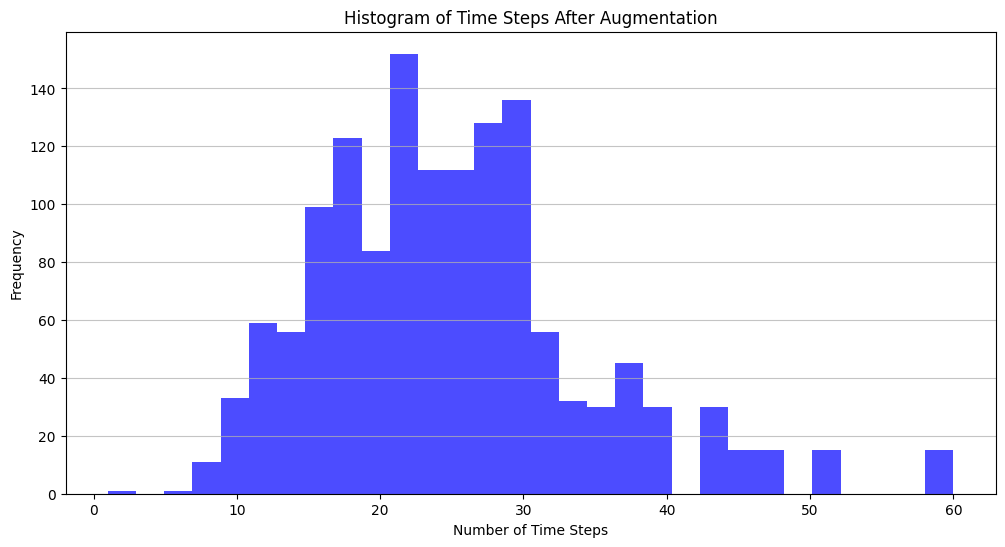

In [13]:
import matplotlib.pyplot as plt

# Get time step lengths for all sips
time_steps = [sip.shape[0] for sip in X]  # X is your final data after augmentation

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(time_steps, bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Time Steps After Augmentation')
plt.xlabel('Number of Time Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [28]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [29]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(1390,)
<class 'numpy.ndarray'>
(26, 64)


In [30]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train, X_aux_train = X[idx[:split1]], y[idx[:split1]], X_aux[idx[:split1]]
X_val,   y_val,   X_aux_val   = X[idx[split1:split2]], y[idx[split1:split2]], X_aux[idx[split1:split2]]
X_test,  y_test,  X_aux_test  = X[idx[split2:]], y[idx[split2:]], X_aux[idx[split2:]]

print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 889 Val 223  Test 278


In [31]:
# Sanity check
for i in range(5):
    print(f"dV: {y_train[i]}, Aux features: {X_aux_train[i]}, Time steps: {len(X_train[i])}")


dV: 39.68254089355469, Aux features: [ 1.  1.  2. 25.], Time steps: 25
dV: 57.099998474121094, Aux features: [ 1.  0.  1. 17.], Time steps: 17
dV: 27.32615089416504, Aux features: [ 1.  3.  0. 13.], Time steps: 13
dV: 26.052888870239258, Aux features: [ 1.  3.  0. 29.], Time steps: 29
dV: 57.14285659790039, Aux features: [ 1.  3.  0. 24.], Time steps: 24


In [32]:
# X_train


In [33]:
# y_train

In [34]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [35]:
# X_train

In [36]:
# # ====================================================================
# # 4. tf.data pipelines
# # ====================================================================
# def generator(xs, ys):
#     for x, y in zip(xs, ys):
#         yield x, y

# output_sig = (
#     tf.TensorSpec((None, 64), tf.float32),
#     tf.TensorSpec((),          tf.float32)
# )

# def make_ds(xs, ys, shuffle=True):
#     ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
#                                         output_signature=output_sig)
#     if shuffle:
#         ds = ds.shuffle(len(xs), seed=42)
#     if BATCH == 1:
#         return ds.repeat().batch(1)              # ragged
#     return ds.repeat().padded_batch(             # padded
#         BATCH,
#         padded_shapes=([None, 64], []),
#         padding_values=(0.0, 0.0)
#     )

# train_ds = make_ds(X_train, y_train_s, shuffle=True)
# val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
# test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [37]:
# ====================================================================
# 4. tf.data pipelines (with auxiliary features)
# ====================================================================
def generator(xs, x_auxs, ys):
    for x, x_aux, y in zip(xs, x_auxs, ys):
        yield {'tof_sequence': x, 'extra_features': x_aux}, y

output_sig = (
    {
        'tof_sequence': tf.TensorSpec((None, 64), tf.float32),
        'extra_features': tf.TensorSpec((X_aux.shape[1],), tf.float32)
    },
    tf.TensorSpec((), tf.float32)
)

def make_ds(xs, x_auxs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, x_auxs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)
    return ds.repeat().padded_batch(
        BATCH,
        padded_shapes=(
            {
                'tof_sequence': [None, 64],
                'extra_features': [X_aux.shape[1]],
            },
            []
        ),
        padding_values=(
            {
                'tof_sequence': 0.0,
                'extra_features': 0.0
            },
            0.0
        )
    )


In [38]:
train_ds = make_ds(X_train, X_aux_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   X_aux_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  X_aux_test,  y_test_s,  shuffle=False)


In [39]:
input_seq = Input(shape=(None, 64), name='tof_sequence')
input_aux = Input(shape=(X_aux.shape[1],), name='extra_features')


In [40]:
train_ds

<_PaddedBatchDataset element_spec=({'tof_sequence': TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), 'extra_features': TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [41]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [42]:
# # ====================================================================
# # 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# # ====================================================================
# inp = tf.keras.Input(shape=(None, 64))
# x = TCN(nb_filters=128,
#         kernel_size=3,
#         dilations=[1,2,4,8,16,32,64],   # ~64-time-step field
#         dropout_rate=0.1,
#         return_sequences=False)(inp)
# out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
# model = tf.keras.Model(inp, out)

# model.compile(
#     optimizer=Adagrad(learning_rate=0.01),
#     loss="mae"                             # MAE is more robust
# )
# model.summary()

# steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
# val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# # weights = (y_train / y_train.max()) ** 0.5  
# cb = tf.keras.callbacks.EarlyStopping(
#          monitor='val_loss', patience=50, restore_best_weights=True)
# model.fit(
#     train_ds,
#     epochs=200,
#     steps_per_epoch=steps_per_epoch,
#     validation_data=val_ds,        # ⬅ use VALIDATION set
#     validation_steps=val_steps,
#     verbose=1,
#     # sample_weight=weights,
#     callbacks=[cb]
# )

In [44]:
# from tensorflow.keras import Input, Model
# from tensorflow.keras.layers import Dense, Concatenate
# from tcn import TCN

# # Input 1: TOF sequence (T, 64)
# input_seq = Input(shape=(None, 64), name='tof_sequence')

# # Input 2: Dense features (like gender, container weight, temp, etc.)
# input_aux = Input(shape=(n_extra_features,), name='extra_features')

# # TCN block
# x = TCN(nb_filters=128,
#         kernel_size=3,
#         dilations=[1, 2, 4, 8, 16, 32, 64],
#         dropout_rate=0.1,
#         return_sequences=False)(input_seq)

# # Concatenate TCN output with auxiliary features
# combined = Concatenate()([x, input_aux])

# # Dense fusion block
# x = Dense(64, activation='relu')(combined)
# output = Dense(1)(x)

# # Define the full model
# model = Model(inputs=[input_seq, input_aux], outputs=output)
# model.compile(optimizer='Adagrad', loss='mae')
# model.summary()


In [45]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

# === Define Inputs ===
# Input 1: TOF sequence (T, 64)
input_seq = Input(shape=(None, 64), name='tof_sequence')

# Input 2: Auxiliary features (gender, container weight, temp, time_steps)
n_extra_features = X_aux_train.shape[1]
input_aux = Input(shape=(n_extra_features,), name='extra_features')

# === TCN Block ===
x = TCN(
    nb_filters=128,
    kernel_size=3,
    dilations=[1, 2, 4, 8, 16, 32, 64],
    dropout_rate=0.1,
    return_sequences=False
)(input_seq)

# === Combine with Auxiliary Input ===
combined = Concatenate()([x, input_aux])

# === Dense Fusion Layer ===, activation='relu'
x = Dense(64)(combined)
output = Dense(1)(x)

# === Build and Compile Model ===
model = Model(inputs=[input_seq, input_aux], outputs=output)
model.compile(optimizer='Adagrad', loss='mae')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tof_sequence        │ (None, None, 64)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn (TCN)           │ (None, 128)       │    673,664 │ tof_sequence[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_features      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132)       │          0 │ tcn[0][0],        │
│ (Concatenate)       │                   │            │ extra_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 682,241 (2.60 MB)

 Trainable params: 682,241 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# === Early stopping callback ===
cb = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# === Epoch step calculation ===
steps_per_epoch = len(X_train) // BATCH + int(len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + int(len(X_val) % BATCH > 0)

# === Train the Model ===
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[cb],
    verbose=1
)


Epoch 1/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 22.6324 - val_loss: 20.1711
Epoch 2/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 16.5433 - val_loss: 14.4560
Epoch 3/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 16.1206 - val_loss: 13.6298
Epoch 4/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 16.9902 - val_loss: 13.2618
Epoch 5/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 16.1403 - val_loss: 13.2211
Epoch 6/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 14.6424 - val_loss: 14.4400
Epoch 7/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 14.1126 - val_loss: 12.2078
Epoch 8/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 14.3743 - val_loss: 13.0719
Epoch 9/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 14.4606 - val_loss: 13.3166
Epoch 10/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 14.2574 - val_loss: 12.1352
Epoch 11/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 13.2497 - val_loss: 14.2047
Epoch 12

In [48]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
# y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
#                      for seq in X_test])
y_pred_s = np.array([
    model.predict(
        {
            'tof_sequence': seq[None, ...],             # shape (1, T, 64)
            'extra_features': aux[None, ...]            # shape (1, 4)
        },
        verbose=0
    )[0, 0]  # extract scalar from output
    for seq, aux in zip(X_test, X_aux_test)
])

# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [49]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 278 test sips
  MSE   : 333.7986
  RMSE  : 18.2702
  R²    : 0.6982
  RMSPE : 47.93%

First 50 predictions:
     Actual dV  Predicted dV
0    59.700001     17.347549
1    19.196865     25.236740
2    80.000000     71.034935
3    99.206352     87.828415
4    41.200001     37.375214
5    18.476191     14.676253
6    80.699997     66.939140
7    16.380953     27.231352
8    39.781746     31.867302
9    99.206352     89.256248
10   14.229249     10.757175
11   62.095238     39.831108
12   41.200001     36.922001
13   12.500000     12.253343
14    9.189723     12.981549
15   36.630753     24.189232
16   78.354553     67.246841
17   18.511263     17.171047
18   28.000000      8.693141
19   22.900000     12.751416
20   38.095238     48.227501
21   17.361111     17.612476
22   32.419197     22.757048
23   57.099998     20.078909
24   36.000000     15.870266
25   21.825397     18.759178
26   27.799999      8.388947
27   99.206352     89.099373
28   14.624506     15.997849
29    5

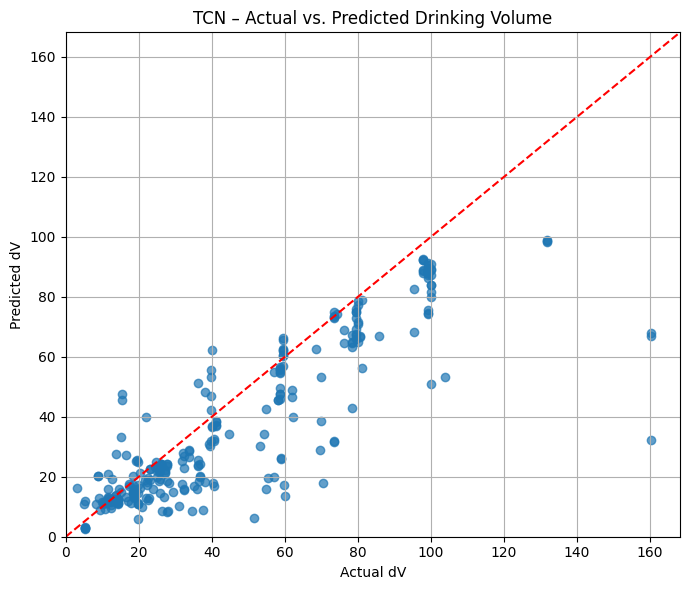

In [50]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [51]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [52]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 1.4691479 160.2
train_s min / max (log): -1.3322176 3.5325873


 # TCN + Dense Feature Fusion